In [ ]:
import base64
import json
import io
import os
import pandas as pd
from PIL import Image
from ultralytics import YOLO
from openai import OpenAI

# Einleitung

## Vorhaben

Dieses Jupyter Notebook soll zeigen, wie mittels einer Objekterkennung inhaltliche Textregionen eines Findmittels erkannt und an eine OCR übergeben werden können. Dies soll es ermöglichen, eine Texterkennung auf ein Formular so anzuwenden, dass die im Formular enthaltenen Informationsbezüge der Texte nicht verloren gehen, auch wenn das Layout des Formulars variiert.

## Ausgangslage

Grundlage ist ein Findmittel des Postkartenherstellers [Verlag Gebrüder Metz](https://de.wikipedia.org/wiki/Gebr%C3%BCder_Metz), dessen Firmenarchiv sich im Besitz des [Hauses der Geschichte Baden-Württemberg](https://www.hdgbw.de/landesgeschichtliche-sammlung/bildarchiv/#gebrueder-metz) befindet. Der Bestand enthält u. a. ca. 200.000 bis 270.000 Glasplatten mit Städte- und Landschaftsaufnahmen aus dem deutschen Südwesten von ca. 1900 bis in die 1960er Jahre. Erschlossen ist der Bestand durch zwei firmeneigene Findmittel: die Plattenbücher - handschriftliche Invetarbücher zu den Fotoaufnahmen - und die sogenannten Blaumappen.

<img src="./imgs_publication/Blaumappe_Meersburg.jpg" alt="Bild einer Seite aus der Blaumappe" width="600"/>
<br><i>Beispielseite aus einer Blaumappe</i>

Die Blaumappen wurden in den 1990ern auf Mikofiche fotografiert, und diese 2023 digitalisiert.

![Beispiel eines Scans](./imgs_publication/Blaumappe_Digitalisiert.png)  
*Digitalisat der Doppelseite einer Blaumappe von einem Mikrofiche*

Insgesamt liegen 1.762 Blaumappen digitalisiert vor, mit jeweils zwischen 15 bis 30 gescannten Doppelseiten. Nicht alle Seiten enthalten Bilder, auch existieren verschiedene Formular-Layouts (s. u.), so dass auch die Anzahl der enthaltenen Bilder pro Scan schwanken kann. Sehr grob geschätzt könnten aber um die 200.000 Motive durch die Blaumappen dokumentiert sein.

### Literatur zur Sammlung Metz

Büchner, Dieter: Ein Denkmal? Viele Denkmale! Das Archiv der Tübinger Postkartenfirma Metz, in: Denkmalpflege in Baden-Württtemberg 2 (2003), S. 187 f.  
Kirchberger, Stefan: Plattenbücher und Blaumappen. Das Metz-Archiv im Haus der Geschichte Baden-Württemberg, in: Das Archiv 4 (2007), S. 74-78.  
Ders: Geschichtsbilder – Das Bildarchiv im Haus der Geschichte Baden-Württemberg, in: Rundbrief Fotografie 21 (2014), 1–2, S. 48–55.  
Krause, Albrecht: Die Sammlung Metz, in: Zu schön, um wahr zu sein. Photographien aus der Sammlung Metz, hg. v. Haus der Geschichte Baden-Württemberg, Stuttgart 1997, S. 17-38.  

## Projektziel

Ziel der KI-gestützten Erschließung ist eine strukturierte Zusammenstellung von Bildmotiv, Bildnummer, Bildtitel und Datierung je Bildeintrag, sowie ggf. noch vorhandenen Ortsbezügen.

![Bild mit Hervorhebungen zu den gewünschten Informationen](./imgs_publication/Blaumappe_Annotationen.png)  
*Beispiel der Angaben zu einem Bild; Grün: gesamter Eintrag, Lila: Foto, Blau: Bildnummer, Rot: Titel, Türkis: Datierung*

Da das Formular-Layout in den Fotomappen variiert und die damaligen Bearbeiter:innen gelegentlich bei ihren Eintragungen von der Vorlage abwichen, soll das Objekterkennungs-Modell [YOLOv8n](https://docs.ultralytics.com/de/models/yolov8/) darauf trainiert werden, die gesuchten Informationen auf den Scans zu klassifizieren, damit gelabelte Bildausschnitte an eine OCR weitergeleitet werden können.

![Variante des Vordrucks](./imgs_publication/Blaumappen_Layout-Alternative_2.png)
![Variante des Vordrucks](./imgs_publication/Blaumappen_Layout-Alternative.png)  
*Varianten des Formulars*

## Bisherige Vorarbeiten

Zum Training des Modells würden 170 Scans in [CVAT](https://www.cvat.ai/) annotiert. Die einzelnen Boxklassen waren:
- *Bild-Text*: Umfasst den gesamten Eintrag zu einem Foto auf einer Seite
- *Bild*: Nur das Foto im Eintrag
- *Bildnummer*: Die Nummer des Glasplattennegativs im Archiv 
- *Titel*: Die Bezeichnung der Aufnahme im Eintrag
- *Datierung*: Die Datums-Angabe zur Aufnahme
- *Ortsbezeichnung*: Ortsbezeichnungen, die im Inhaltsverzeichnis der Mappen oder als Überschrift auf den Bildseiten vorkommen. Ortsnamen im Bildtitel wurden nicht zusätzlich als Ortsbezeichnung gelabelt.
- *Ortsbuchstabe*: Ein an den oberen Seitenecken notierter Buchstabe, der auf die Ortsbezeichnung im Inhaltsverzeichnis der Mappe referiert.

Anschließend wurde das annotierte Material im Verhältnis 9:1 in ein Trainings- und ein Validierungsset aufgeteilt, wobei auf die Anwesenheit von selten vertretenen Klassen in beiden Sets geachtet wurde. 

Das Training des YOLOv8n-Modells mit 100 Epochen auf einem Microsoft Surface mit 12th Gen Intel Core i5-1235U dauerte ca. 217 min, und war mit Abstrichen bei im Trainingsset sehr seltenen Klassen *Ortsbezeichnung* und *Ortsbuchstabe* sehr erfolgreich.

<img src="./imgs_publication/results.png" alt="Trainingsmetriken im Verlauf der Epochen" width="800"/>
<br><i>Validierung der Modellperformance nach jeder Trainingsepoche</i>
<br><br>
<img src="./imgs_publication/confusion_matrix_normalized.png" alt="Confusion-Matrix für die Boxklassen" width="600"/>
<br><i>Die Confusion-Matrix</i>

## Vorliegendes Proof-of-Concept

Mit dem Proof-of-Concept soll gezeigt werden, dass 

- das Modell erfolgreich die relevanten Bereiche in einem für das Modell unbekannten Bild erkennt, 
- die in der Objekterkennung erhaltenen Bildbereiche an eine OCR übergeben werden können, 
- die Informationen zu den einzelnen Einträgen gruppiert werden können, 
- und am Ende eine strukturierte Ausgabe erzeugt werden kann.

Die strukturierte Ausgabe soll in diesem PoC zu jeden Bildeintrag auf dem Scan enthalten: 

- ein Bildausschnitt zum Blaumappeneintrag inkl. Bild und Eintragungen 
- die OCR-Ergebnisse zu den einzelnen Feldern Bildnummer, Titel und Datierung
- sowie die OCR-Ergebnisse zu diesen Feldern, wenn der gesamte Eintag (Label "Bild-Text") Grundlage der Texterkennung war
- die Token-Kosten für die Texterkennung je Vorgang

Die Texterkennung erfolgte mit dem Qwen-Modell [Qwen3-VL-8B-Instruct](https://huggingface.co/Qwen/Qwen3-VL-8B-Instruct) über die API der Alibaba Cloud.



# Proof of Concept

## Layouterkennung

Laden der Bilddatei

In [2]:
PATH_TO_IMAGE = "1470-0002.jpg"

Laden des trainierten Modells

In [3]:
PATH_TO_MODEL = "best.pt"

In [4]:
trained_model = YOLO(PATH_TO_MODEL)

Durchführen der Objekterkennung

In [ ]:
results = trained_model.predict(
    PATH_TO_IMAGE,
#    visualize=True,
    save=True,
    project="proof-of-concept-results",
    save_txt=True,
    show=True,
    save_crop=True
)


image 1/1 p:\08_Digitale_Strategie\2025_Metz-Blaumappen-Erfassung\02_proof-of-concept\1470-0002.jpg: 512x800 16 Bildnummers, 17 Titels, 16 Datierungs, 16 Bilds, 16 Bild-Texts, 176.0ms
Speed: 11.2ms preprocess, 176.0ms inference, 9.6ms postprocess per image at shape (1, 3, 512, 800)
Results saved to \\10.0.5.5\Projekte\08_Digitale_Strategie\2025_Metz-Blaumappen-Erfassung\02_proof-of-concept\runs\detect\proof-of-concept-results\predict-7
1 label saved to \\10.0.5.5\Projekte\08_Digitale_Strategie\2025_Metz-Blaumappen-Erfassung\02_proof-of-concept\runs\detect\proof-of-concept-results\predict-7\labels


### Bericht: erkannte Labels pro Datei

In [6]:
for result in results:
    print(f"Für {result.path.split("\\")[-1]}:\n") # Ausagbe Dateinamen
    # TODO: os.path.basename(result.path) verwenden, um Dateinamen zu extrahieren

    count_cls_dict = dict()  # Dict zum Sammeln der Häufigkeiten pro Klasse

    # Häufigkeit jeder Klasse in cls-Attribute von Boxes im Dictionary speichern
    for cls in result.names:
        count_cls_dict[cls] = list(result.boxes.cls).count(cls)

    # Nummern der Klassen durch Klassenlabels in Dictionary ersetzen
    for cls in result.names:
        class_label = result.names[cls]
        count_cls_dict[class_label] = count_cls_dict.pop(cls)

    # Ausgabe der Anzahl pro Klasse
    for class_label, count in count_cls_dict.items():
        print(f"\t{class_label}: {count}")


Für 1470-0002.jpg:

	Bildnummer: 16
	Titel: 17
	Datierung: 16
	Bild: 16
	Ortsbezeichnung: 0
	Bild-Text: 16
	Ortsbuchstabe: 0


## Nachbearbeitung

### Konvertierung

DataFrame für Bildpfad, Klasse, Confidence, Koordinaten xywh, xywhn, xyxy, xyxyn

In [7]:
boxes_df = pd.DataFrame(columns=["filepath", "cls", "confidence", "xywh", "xywhn", "xyxy", "xyxyn"])

Auslesen der Werte der Objekterkennung in das DataFrame

In [8]:
for result in results:
    for box in result.boxes:
        record = ["", box.cls.item(), box.conf.item(), box.xywh[0], box.xywhn[0], box.xyxy[0], box.xyxyn[0]]
        boxes_df.loc[len(boxes_df)] = record
    
    # Klassifizierungs-IDs durch Klassen-Titel ersetzen
    box_names_dict = result.names
    boxes_df["cls"] = boxes_df["cls"].map(box_names_dict)

    # Pfad zur Bilddatei
    filepath = result.path
    boxes_df["filepath"] = filepath
    

### Gruppierung

Spalte für Group-ID erstellen und jedem Bild-Text eine ID zuweisen.

In [9]:
def initiate_groups(df):
    """
    Ergänzt die Spalte group_id nach Spalte filepath. Datensätze zu Bild-Text-Labels erhalten eindeutige group_ids.
    """

    df.loc[df["cls"] == "Bild-Text", "group_id"] = list(range(len(boxes_df[boxes_df.cls == "Bild-Text"])))
 
    df = df[['filepath', 'group_id', 'cls', 'confidence', 'xywh', 'xywhn', 'xyxy', 'xyxyn']]

    return df

**Verbessern**: Gruppennummern von links oben nach rechts unten vergeben:  
-> Bild-Text-Boxes sortieren nach x1, y1

**TODO:** Gruppieren anhand der absoulten (xyxy, xywh) wie relativen Koordianten (xyxyn, xywhn)  
**TODO:** confidence-Schwellert: Boxen ab bestimmten confidence-Wert übernehmen

In [10]:
boxes_df = initiate_groups(boxes_df)

Gruppieren der restlichen Labels: Alle Lables, deren Box-Mittelpunkt (x- und y-Werte aus xywh) innerhalb einer Bild-Text-Box liegen (xyxy) erhalten dessen Group-ID

In [11]:
for i in boxes_df[boxes_df.cls == "Bild-Text"].index:

    # Koordianten der Eckpunkte von Bild-Text
    x1 = float(boxes_df.xyxy[i][0])
    y1 = float(boxes_df.xyxy[i][1])
    x2 = float(boxes_df.xyxy[i][2])
    y2 = float(boxes_df.xyxy[i][3])
    
    # Group_id des Bild-Texts 
    box_group_id = boxes_df.group_id[i].item()

    # Setze die Group-Id bei allen nicht-Bild-Text-Labels, deren Box-Mittelpunkte innerhalb der Koordinaten des Bild-Text liegen,
    # auf die der Bild-Text-Box
    boxes_df.loc[
        (boxes_df.cls != "Bild-Text") 
        & (boxes_df.xywh.str[0].astype(float) > x1 ) 
        & (boxes_df.xywh.str[0].astype(float) < x2 ) 
        & (boxes_df.xywh.str[1].astype(float) > y1 ) 
        & (boxes_df.xywh.str[1].astype(float) < y2 ),
        "group_id"]  = box_group_id

### Bericht: Gruppierung

Übersicht über die Anzahl der Boxen pro Gruppe und Label:

In [12]:
# Übersicht über die Anzahl der Boxen pro Gruppe und Label
print(boxes_df.pivot_table(index=["filepath", "group_id"], columns="cls", aggfunc="size", fill_value=0).to_string())

cls                                                                                                 Bild  Bild-Text  Bildnummer  Datierung  Titel
filepath                                                                                  group_id                                               
p:\08_Digitale_Strategie\2025_Metz-Blaumappen-Erfassung\02_proof-of-concept\1470-0002.jpg 0.0          1          1           1          1      2
                                                                                          1.0          1          1           1          1      1
                                                                                          2.0          1          1           1          1      1
                                                                                          3.0          1          1           1          1      1
                                                                                          4.0          1          1         

Anzahl der Boxen, die keiner Gruppe zugeordnet werden konnten, pro Label:

In [13]:
if boxes_df["group_id"].isna().sum() > 0:
    print(boxes_df.loc[boxes_df["group_id"].isna(), "cls"].value_counts().to_string())
else:
    print("Alle Boxen konnten einer Gruppe zugeordnet werden.")

Alle Boxen konnten einer Gruppe zugeordnet werden.


## OCR mit Qwen

Hilfsfunktionen:

In [14]:
def crop_image(image:Image, xyxy:list[str|float]) -> Image:
    """Erstelle eines Bildausschnitts

    Args:
        image: Das Ausgangsbild als PIL-Objekt
        xyxy: Die absoluten Koordinaten der linken oberen und rechten unteren Ecke des Bildausschnitts in einer Liste

    Returns:
        PIL-Objekt
    """

    x1, y1, x2, y2 = map(float, xyxy)

    cropped_image = image.crop((x1, y1, x2, y2))
    
    return cropped_image

In [15]:
def pil_image_to_base64(image:Image) -> str:
    """Konvertiert ein PIL-Image in einen base64-String

    Args:
        image: PIL-Image
    
    Returns:
        String 
    """
    buffered = io.BytesIO()
    image.save(buffered, format="JPEG")
    img_bytes = buffered.getvalue()
    return base64.b64encode(img_bytes).decode("utf-8")

Funktion zum Senden von Bildern mit Prompts an Qwen-API:

In [ ]:
def qwen_ocr(
        image:Image, 
        api_key:str, 
        endpoint:str, 
        modell:str = "qwen3-vl-8b-instruct", 
        prompt:str = "Extrahiere den Text aus diesem Bild"
        ) -> json:
    # TODO: als Model mal mit 2b und 32b versuchen, bzw. "qwen-vl-ocr-latest"
    """Senden eines PIL-Images an die Qwen-API mit prompt-Anweisung für OCR/HTR/ATR.

    Args:
        image: Das Bild als PIL-Objekt
        api_key: String des API-Keys
        endpoint: String der Base-URL des eigenen Alibaba-Kontos
        modell: String des zu verwendeten Qwen-Modells (default "qwen3-vl-8b-instruct")
        prompt: String der Promptanweisung für das Qwen-Modell (default "Extrahiere den Text aus diesem Bild")

    Returns:
        Qwen-Response als JSON-Objekt (vgl. https://www.alibabacloud.com/help/en/model-studio/qwen-vl-ocr) oder Error-Message als String.
    """

    # Bildausschnitt in base64 konvertieren:
    img_base64 = pil_image_to_base64(image)
    
    # Senden an Qwen

    try:
        client = OpenAI(
            api_key=api_key,
            base_url=endpoint,
        )

        completion = client.chat.completions.create(
            model = modell,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image_url",
                            "image_url": {"url":f"data:image/jpeg;base64,{img_base64}"}
                        },
                        {
                            "type": "text",
                            "text": prompt
                        }
                    ]
                }
            ])
                    
        return completion.model_dump_json()
        
    except Exception as e:
        
        error_message = f"Error message: {e}"
        
        return error_message

    

Prompt-Texte für die Text-Extraktion.  
- Für die Bildausschnitte zu einem gesamten Eintrag (Label "Bild-Text"): 

In [ ]:
PROMPT_EXTRACT_RECORD = """
Extrahiere die Bildnummer, die Bezeichnung und das Datum aus dem Bild.
Du musst die Informationen korrekt extrahieren. Lass keine Informationen aus oder erfinde neue.
Gib die Daten im folgenden Format wieder: {'Bildnummer': 'xxx', 'Bezeichnung': 'xxx', 'Datum': 'xxx'}
"""

- Für die Bildausschnitte zu einzelnen Felder. Der Feldtitel soll im Prompt genannt werden:

In [ ]:
def prompt_extract_field(field:str) -> str:
    return f"Transkribiere den Eintrag zum Feld {field}"

Bild für Bildausschnitte via PIL laden

In [16]:
image = Image.open(PATH_TO_IMAGE)

Anmeldedaten:

In [18]:
API_KEY = os.getenv("alibaba_api_key")
ENDPOINT = os.getenv("alibaba_api_endpoint")

Durchführen der OCR mit Qwen:

In [63]:
for i in boxes_df.loc[(boxes_df["cls"] != "Bild")].index:

    # Prompt je nach Feldtyp auswählen
    if boxes_df.at[i, "cls"] == "Bild-Text":
        prompt = PROMPT_EXTRACT_RECORD
    else:
        prompt = prompt_extract_field(boxes_df.at[i, "cls"])

    # Bildausschnitt erstellen
    cropped_image = crop_image(image, boxes_df.loc[i].xyxy)
    
    # Senden an Qwen
    qwen_response = qwen_ocr(cropped_image, API_KEY, ENDPOINT, prompt=prompt)

    # Sichern im DataFrame
    boxes_df.at[i, "qwen_response"] = qwen_response

## Ausgabe

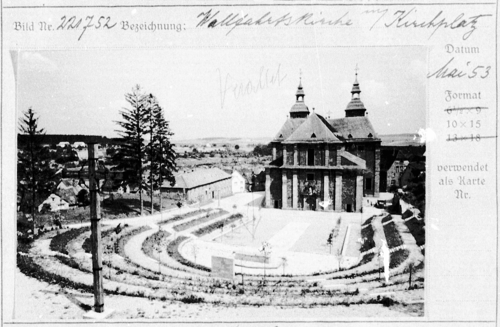

                                                                                                content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '221752', 'Bezeichnung': 'Wallfahrtskirche / Kirchplatz', 'Datum': 'Mai 53'}                  82                 2482                      41        2605
Bildnummer                                                                              Bild Nr. 221752                  19                   66                      12          97
Titel                                                                     Bezeichnung: Wallfahrtskirche                  19                  172                      11         202
Datierung                                                                                Datum: Mai '53                  19                   72                       7          98


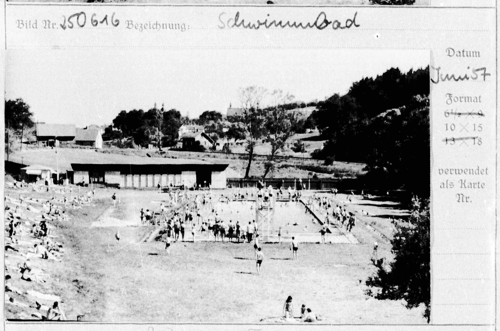

                                                                              content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '250616', 'Bezeichnung': 'Schwimmbad', 'Datum': 'Juni 57'}                  82                 2544                      35        2661
Bildnummer                                                            Bild Nr. 250616                  19                   74                      12         105
Titel                                                         Bezeichnung: Schwimmbad                  19                  177                       8         204
Datierung                                                              Datum: Juni 57                  19                   72                       7          98


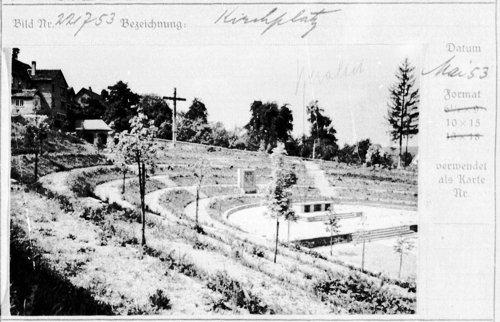

                                                                             content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '221753', 'Bezeichnung': 'Kirchplatz', 'Datum': 'Mai 53'}                  82                 2482                      34        2598
Bildnummer                                                           Bild Nr. 221253                  19                   66                      12          97
Titel                                                        Bezeichnung: Kirchplatz                  19                  162                       8         189
Datierung                                                             Datum: Mai '53                  19                   72                       7          98


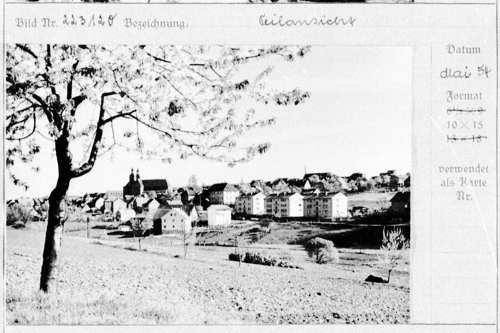

                                                                               content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '223/20', 'Bezeichnung': 'Teilansicht', 'Datum': 'dlai 54'}                  82                 2503                      35        2620
Bildnummer                                                             Bild Nr. 223/20                  19                   66                      12          97
Titel                                                         Bezeichnung: Teilansicht                  19                  104                       8         131
Datierung                                                                Datum: Mai 54                  19                   72                       7          98


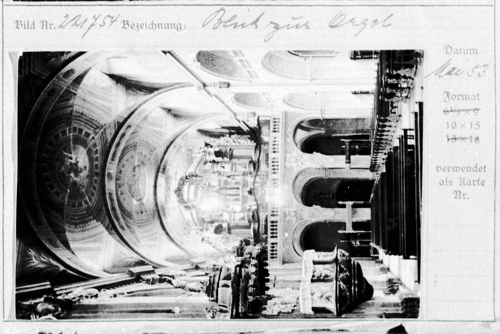

                                                                                   content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '241754', 'Bezeichnung': 'Blick zur Orgel', 'Datum': 'März 53'}                  82                 2503                      37        2622
Bildnummer                                                                 Bild Nr. 201754                  19                   66                      12          97
Titel                                                         Bezeichnung: Blick zur Orgel                  19                  212                       9         240
Datierung                                                                    Datum: Mai 53                  19                   72                       7          98


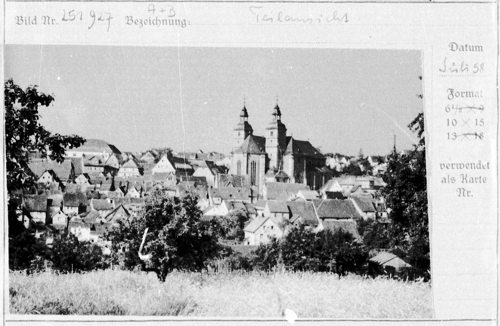

                                                                               content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '257927', 'Bezeichnung': 'Teilansicht', 'Datum': 'Juli 58'}                  82                 2482                      35        2599
Bildnummer                                                             Bild Nr. 257927                  19                   77                      12         108
Titel                                                         Bezeichnung: Teilansicht                  19                  212                       8         239
Datierung                                                               Datum: Juli 58                  19                   72                       7          98


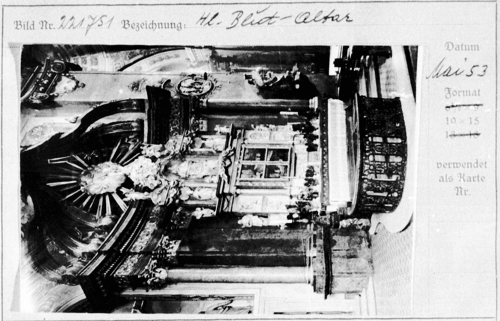

                                                                                 content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '221751', 'Bezeichnung': 'Hl. Blut-Altar', 'Datum': 'Mai 53'}                  82                 2522                      39        2643
Bildnummer                                                               Bild Nr. 221751                  19                   66                      12          97
Titel                                                        Bezeichnung: Hl. Blut-Altar                  19                  142                      13         174
Datierung                                                                 Datum: Mai '53                  19                   72                       7          98


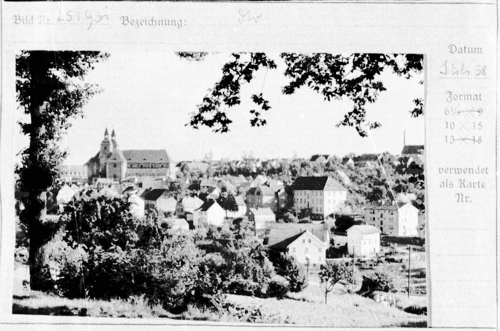

                                                                      content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '251931', 'Bezeichnung': 'GW', 'Datum': 'Juli 58'}                  82                 2544                      32        2658
Bildnummer                                                    Bild Nr. 251933                  19                   77                      12         108
Titel                                                         Bezeichnung: SW                  19                  112                       6         137
Datierung                                                   Datum: 5. Juli 58                  19                   72                      10         101


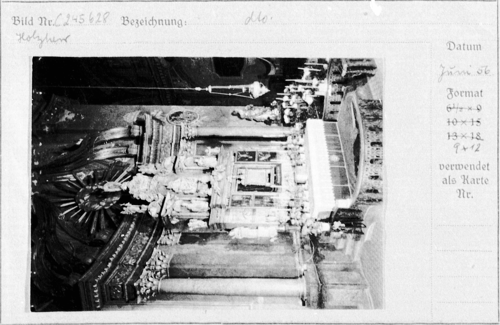

                                                                                 content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '245628', 'Bezeichnung': 'Holzheiligtum', 'Datum': 'Juni 56'}                  82                 2482                      37        2601
Bildnummer                                                            Bild Nr. C 245 628                  19                   66                      14          99
Titel                                                                   Bezeichnung: Mo.                  19                  122                       7         148
Datierung                                                                Datum: Juni '56                  19                   72                       7          98


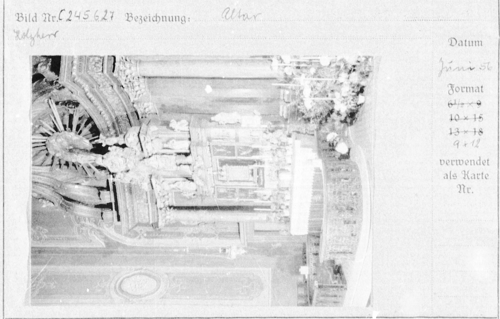

                                                                          content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': 'C245627', 'Bezeichnung': 'Altar', 'Datum': 'Juni 56'}                  82                 2522                      34        2638
Bildnummer                                                       Bild Nr. C245627                  19                   77                      12         108
Titel                                                          Bezeichnung: Altar                  19                   90                       7         116
Datierung                                                          Datum: Juni 56                  19                   74                       7         100


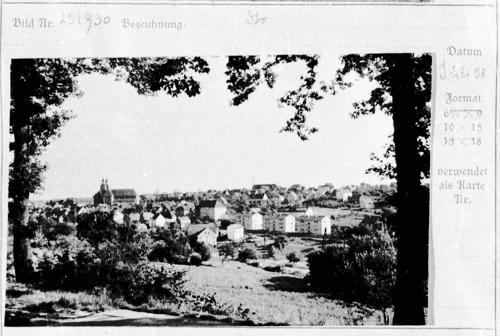

                                                                       content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '251930', 'Bezeichnung': 'Sto', 'Datum': 'Juli 58'}                  82                 2503                      33        2618
Bildnummer                                                     Bild Nr. 251930                  19                   82                      12         113
Titel                                                         Bezeichnung: Dto                  19                  122                       7         148
Datierung                                                       Datum: Juli 58                  19                   82                       7         108


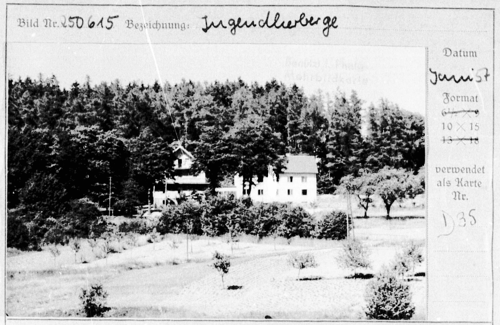

                                                                                  content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '250615', 'Bezeichnung': 'Jugendherberge', 'Datum': 'Juni 57'}                  82                 2482                      37        2601
Bildnummer                                                                Bild Nr. 250615                  19                   70                      12         101
Titel                                                         Bezeichnung: Jugendherberge                  19                  200                       9         228
Datierung                                                                Datum: Juni 1957                  19                   72                       9         100


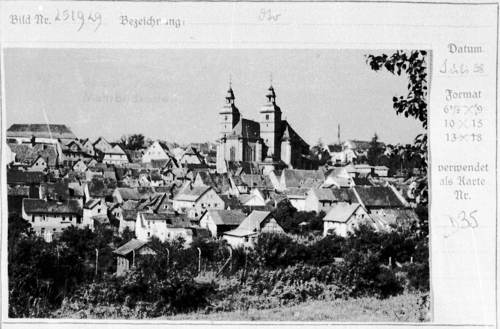

                                                                       content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '251929', 'Bezeichnung': '915', 'Datum': 'Juli 58'}                  82                 2544                      34        2660
Bildnummer                                                     Bild Nr. 251929                  19                   82                      12         113
Titel                                                         Bezeichnung: 915                  19                  132                       9         160
Datierung                                                       Datum: Juli 58                  19                   82                       7         108


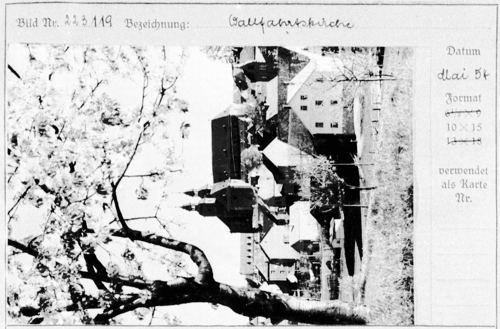

                                                                                      content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '223119', 'Bezeichnung': 'Galliganskirche', 'Datum': '24. Mai 54'}                  82                 2544                      38        2664
Bildnummer                                                                    Bild Nr. 223119                  19                   66                      12          97
Titel                                                              Bezeichnung: Galfanskirche                  19                  142                      10         171
Datierung                                                                       Datum: Mai 54                  19                   72                       7          98


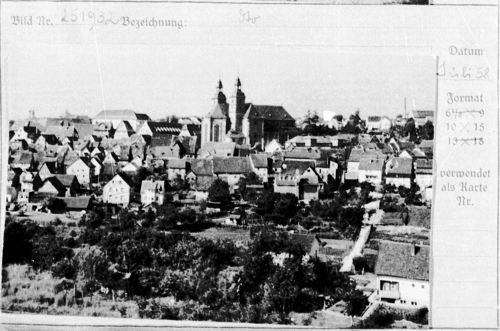

                                                                        content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '251932', 'Bezeichnung': 'Gloß', 'Datum': 'Juli 58'}                  82                 2544                      34        2660
Bildnummer                                                     Bild Nr. 2519321                  19                   70                      13         102
Titel                                                           Bezeichnung: Mr                  19                  117                       6         142
Datierung                                                     Datum: 5. Juli 58                  19                   72                      10         101


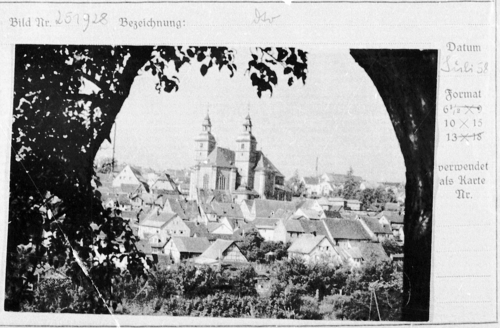

                                                                       content  prompt text tokens  prompt image tokens  completion text tokens  sum tokens
Bild-Text   {'Bildnummer': '251928', 'Bezeichnung': 'Dav', 'Datum': 'Juli 58'}                  82                 2482                      33        2597
Bildnummer                                                     Bild Nr. 251928                  19                   70                      12         101
Titel                                                             Bezeichnung:                  19                  127                       5         151
Datierung                                                    Datum: 5. Juli 58                  19                   72                      10         101


In [ ]:
for i in boxes_df.loc[boxes_df["cls"] == "Bild-Text"].index:

    group_id = boxes_df.group_id[i]

    x1, y1, x2, y2 = map(float, boxes_df.loc[i].xyxy)

    # Bildausschnitt mit PIL
    cropped_image = image.crop((x1, y1, x2, y2))

    # Bildausschnitt verkleinern
    w, h = cropped_image.size
    new_w = 500
    new_h = int(h * (new_w / w))
    cropped_image = cropped_image.resize((new_w, new_h))

    display(cropped_image)

    # Sichern des Bildausschnitts
    cropped_image.save(f"./groups_images/cropped_image_group_{int(group_id)}.jpg")

    # Dataframe für Anzeige der OCR-Ergebnisse
    df = pd.DataFrame(columns=["content", "prompt text tokens", "prompt image tokens", "completion text tokens", "sum tokens"])

    for field in ["Bild-Text", "Bildnummer", "Titel", "Datierung"]:

        # Für den Fall, dass mehrere Boxen zu einem Label in einem Bild erkannt wurden:
        for j in boxes_df.loc[(boxes_df.group_id == group_id) & (boxes_df.cls == field)].index:

            # JSON der Qwen-Antwort parsen
            qwen_response_json = json.loads(boxes_df.at[j, "qwen_response"])

            # Inhalte aus JSON holen
            content = qwen_response_json["choices"][0]["message"]["content"]
            prompt_text_tokens = qwen_response_json["usage"]["prompt_tokens_details"]["text_tokens"]
            prompt_image_tokens = qwen_response_json["usage"]["prompt_tokens_details"]["image_tokens"]
            completion_text_tokens= qwen_response_json["usage"]["completion_tokens_details"]["text_tokens"]
            sum_tokens = prompt_text_tokens + prompt_image_tokens + completion_text_tokens

            # Inhalte im DataFrame ergänzen
            df.loc[field] = [content, prompt_text_tokens, prompt_image_tokens, completion_text_tokens, sum_tokens]
            
    print(df.to_string())

Sichern der Ergbenisse in einer CSV

In [25]:
boxes_df.to_csv("./proof-of-concept_final-results.csv", index=False)

# Fazit

## Objekterkennung

Das trainierte YOLO-Modell erkannte im ihm unbekannten Bild mit hoher Zuverlässigkeit die relevanten Regions of Interest.

Die einzelnen Informationen konnten zu ihren Einträgen zugeordnet werden, und es war möglich, die einzelnen Informationen gezielt als Bildausschnitte an die Texerkennung zu senden und die Ergebnisse wieder dem Eintrag in der richtigen Kategorie zuzuordnen.

Eine struktrierte Ablage erfolgte als csv.

## Texterkennung

Die Ergebnise der OCR wiesen keine gravierenden Probleme auf. 
Besonders die Ergebnisse zu den Bildausschnitten eines kompletten Eintrags zeigen, dass mittels eines VLM-Modells wie Qwen mit dessen Möglichkeit, via Prompt gesuchte Informationen und gewünschtes Ausgabeformat vorzugeben, auf das eigene Training eines Objekterkennungs-Modells prinzipiell verzichtet werden könnte. 

Im Falle der Blaumappen erleichterte die Verwendung von YOLO dennoch das Erstellen der Bildausschnitte zum Eintrag für die Ablage im Sammlungsdokumentationssystem. Vergleicht man die aufgewendete Tokens, wurden für die Texterkennung mittels gesamten Eintrag durchschnittlich das Siebenfache an Tokens verwendet, wie für die einzelnen Felder eines Bildes zusammengenommen. Dies lag ausschließlich an der Größe des Bildausschnitts. Die Vorbereitung durch ein eigenes Objekterkennungs-Modell kann somit besonders interessant sein, wenn es darum geht, den Aufwand für das VLM-Modell zu verringern, um z. B. Bearbeitungskosten oder Rechenzeiten zu verringern.